In [9]:
import pyrealsense2 as rs
import numpy as np
import cv2
import time
from RealSenseTools import list_realsense_devices

In [19]:
## Parameters of the videos

VideoNumber = 4
#VideoName = ".\Videos_RS\Video" + str(VideoNumber)
#############################################
# For recording calibration videos I would recomend to save them in a different folder 
VideoName = ".\Calibration_Videos_RS\Calib_Video" + str(VideoNumber)
#############################################
VideoL = 5 # Duration of the video in seconds


## I wouldn't change these 
Time_info = VideoName + '_t'
Width = 1280
Height = 720
FPS = 30

## Check that two cameras are connected and retreive their serial number

In [20]:
SN = list_realsense_devices()

Found 2 connected RealSense devices:

--- Device 1 ---
  Name: Intel RealSense D555
  Serial Number: 353522301236
  Firmware Version: 7.56.19918.835
  Product ID: 0x0B56

--- Device 2 ---
  Name: Intel RealSense D555
  Serial Number: 353522300887
  Firmware Version: 7.56.19919.4144
  Product ID: 0x0B56


## Record 2 videos and stream 1 video with two views

In [22]:
# Serial numbers for the two cameras
serial1 = SN[0] # Camera 1 serial number
serial2 = SN[1] # Camera 2 serial number

# Initialise pipelines
pipe1 = rs.pipeline()
pipe2 = rs.pipeline()
config1 = rs.config()
config2 = rs.config()

# Enable streams
config1.enable_device(serial1)
config1.enable_stream(rs.stream.depth, Width, Height, rs.format.z16, FPS)
config1.enable_stream(rs.stream.color, Width, Height, rs.format.bgr8, FPS)

config2.enable_device(serial2)
config2.enable_stream(rs.stream.depth, Width, Height, rs.format.z16, FPS)
config2.enable_stream(rs.stream.color, Width, Height, rs.format.bgr8, FPS)

# Start pipelines
pipe1.start(config1)
pipe2.start(config2)

## set videos to save recordings

# Define the codec and create VideoWriter object
fourcc1 = cv2.VideoWriter_fourcc(*'XVID')
out1 = cv2.VideoWriter(VideoName+'A.avi', fourcc1, FPS, (Width, Height))

fourcc2 = cv2.VideoWriter_fourcc(*'XVID')
out2 = cv2.VideoWriter(VideoName+'B.avi', fourcc2, FPS, (Width, Height))

t = np.empty((int(VideoL*FPS*1.2),))
t[:] = np.nan
t0 = time.time()

counter = 1


try:
    while True:
        # Get frames from both cameras
        frames1 = pipe1.wait_for_frames()
        frames2 = pipe2.wait_for_frames()
        color_frame1 = frames1.get_color_frame()
        color_frame2 = frames2.get_color_frame()
        if not color_frame1:
            continue

        # Convert images to numpy arrays
        color_image1 = np.asanyarray(color_frame1.get_data())
        color_image2 = np.asanyarray(color_frame2.get_data())

        # Save the frame
        out1.write(color_image1)
        out2.write(color_image2)

        # contatenate for displaying purposes
        frame_cat = cv2.hconcat([color_image1,color_image2])
        half = cv2.resize(frame_cat, (0, 0), fx = 0.5, fy = 0.5)
        cv2.imshow('frame', half)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

        if counter == 1:  
            t[0] = time.time()
            
        else:
            t[counter-1] = time.time()-t[0]

        elapsed = time.time() - t[0]
        counter = counter+1
        
        if  elapsed>=VideoL:
            break
finally:
    pipe1.stop()
    pipe2.stop()
    out1.release()
    out2.release()
    cv2.destroyAllWindows()
    np.savez(Time_info, t=t)

## Optional: Check speed of recording

Text(0, 0.5, 'Delta t')

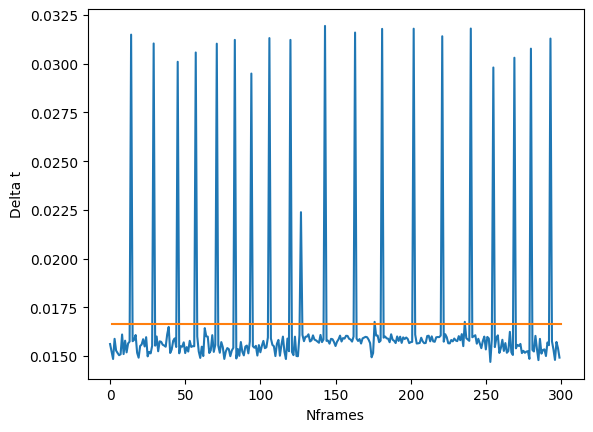

In [5]:
import matplotlib.pyplot as plt
plt.plot(t[2:]-t[1:-1])
plt.plot([1,VideoL*FPS],[1/FPS, 1/FPS])
plt.xlabel('Nframes')
plt.ylabel('Delta t')